# Welcome to the `gridops` quickstarter!


`gridops` is an open-source and customizable grid operations modeling framework for the three major U.S. interconnections (Western, Eastern, ERCOT). Production cost modeling in `gridops` utilizes linear DC Optimal Power Flow (DC-OPF) approximation to optimize hourly unit commitment (UC) and economic dispatch (ED) processes over a user-configurable rolling horizon.

`gridops` was created to:
  - Address weather and water dynamics and associated vulnerabilities in U.S. bulk power systems,
  - Link with a wide range of hydrometeorological datasets and energy system/machine learning models to explore future uncertainty in grid operations,
  - Analyze current and future grid stress and reliability trends under a wide range of weather conditions, generation mixes, and demand growth scenarios.
  - Create simple and user-tailored representations of the U.S. interconnections to find a balance between model accuracy and run time to answer research questions of interest.

# An example simulation!
Let's start using `gridops` by initilizing a simulation! First, we load the package.

In [1]:
# Import the package and check the package version
import gridops as go
from importlib.metadata import version
print(f"Package version: {version('gridops')}")

Package version: 0.1.0


Next, we initialize our `Model` object where we can specify the interconnection we'd like to simulate, mathematical formulation we'd like to use, and solver we'll utilize.

In [2]:
# Instantiate the model
model = go.Model(
    region="west",                           # U.S. Western Interconnection
    problem="linear",                        # Linear programming (economic dispatch only)
    solver_name="appsi_highs",               # Using open-source HiGHS solver
    solver_params={"log_to_console": False, 
                   "output_flag": False},    # Optional – preventing HiGHS from printing to console
)

2026-06-15 12:24:23,093 - INFO - gridops.model - Configuration: U.S. Western Interconnection - Economic Dispatch


Then, we point out our example configuration file (see `gridops/data/example_config_file.yml` for a full template) and number of days we'd like to simulate to start the simulation.

In [3]:
# Access the example configuration file
from importlib.resources import files
config_file_path = files("gridops").joinpath("data/example_config_file.yml")

# Changing the directory to the location of the configuration file (only needed if the paths in the config file are relative 
# to the config file's location, otherwise (i.e., absolute paths in the config file), this step would not be necessary)
import os
os.chdir(files("gridops").joinpath("data"))

# Run for 2 days with a 24-hour rolling horizon
model.run(
    config_file=config_file_path,  # Path to the model configuration file
    n_days=2,                      # Running for 2 days
    horizon_hours=24,              # Optional – using default 24-hour horizon
)

2026-06-15 12:24:23,405 - INFO - gridops.west.launch - Preparing the U.S. Western Interconnection economic dispatch simulation.
2026-06-15 12:24:23,407 - INFO - gridops.configuration - Loading configuration file.
2026-06-15 12:24:23,436 - INFO - gridops.configuration - generator_parameters_file = example_inputs/data_genparams.csv
2026-06-15 12:24:23,439 - INFO - gridops.configuration - generator_matrix_file = example_inputs/gen_mat.csv
2026-06-15 12:24:23,440 - INFO - gridops.configuration - line_to_bus_file = example_inputs/line_to_bus.csv
2026-06-15 12:24:23,443 - INFO - gridops.configuration - line_parameters_file = example_inputs/line_param.csv
2026-06-15 12:24:23,445 - INFO - gridops.configuration - daily_hydro_maximum_file = example_inputs/hydro_max.csv
2026-06-15 12:24:23,447 - INFO - gridops.configuration - daily_hydro_minimum_file = example_inputs/hydro_min.csv
2026-06-15 12:24:23,449 - INFO - gridops.configuration - daily_hydro_total_file = example_inputs/hydro_total.csv
2026

Running HiGHS 1.12.0 (git hash: 755a8e0): Copyright (c) 2025 HiGHS under MIT licence terms


2026-06-15 12:26:57,734 - INFO - gridops.west.launch - Horizon 0: Optimization complete.
2026-06-15 12:26:57,842 - INFO - gridops.west.launch - Horizon 0 (day 1) completed.
2026-06-15 12:26:57,842 - INFO - gridops.west.launch - Horizon 2 / 2  (day 2, hours 25-48)
2026-06-15 12:26:57,842 - INFO - gridops.west.launch - Horizon 1: Cleared HiGHS solver state (warmstart=False).
2026-06-15 12:26:57,842 - INFO - gridops.west.launch - Horizon 1: Updating parameters.
2026-06-15 12:26:58,956 - INFO - gridops.west.launch - Horizon 1: Starting optimization.
2026-06-15 12:28:37,675 - INFO - gridops.west.launch - Horizon 1: Optimization complete.
2026-06-15 12:28:38,157 - INFO - gridops.west.launch - Horizon 1 (day 2) completed.
2026-06-15 12:28:38,159 - INFO - gridops.west.launch - Writing output files.
2026-06-15 12:28:38,349 - INFO - gridops.west.launch - All outputs written.
2026-06-15 12:28:38,358 - INFO - gridops.model - All horizons completed successfully.


Here, we analyze the results and create figures with the simulation outputs. First, let's look at the locational marginal price (LMP) and loss of load results. In this example, we use `pandas`, `numpy` and `matplotlib` packages to analyze/visualize the results.

In [4]:
# Import packages for post-processing and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define the number of days and hours simulated
total_days = 2
total_hours = total_days*24

# Read the LMP and loss of load outputs
LMPs = pd.read_parquet("example_outputs/duals.parquet")
Loss_of_load = pd.read_parquet("example_outputs/slack.parquet")

# Look at the first few rows of the LMPs
LMPs.head()

,Node,Time,Value
0,bus_100011,1,47.434764
1,bus_100011,2,46.566050
2,bus_100011,3,46.711186
3,bus_100011,4,45.626340
4,bus_100011,5,47.444308


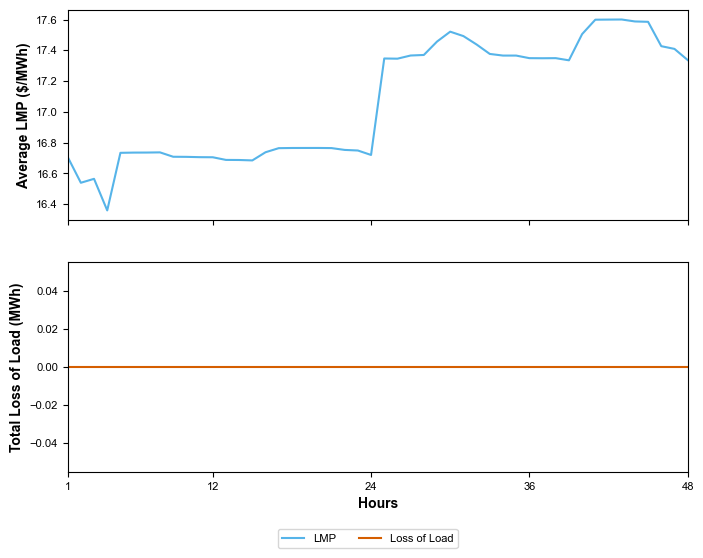

<Figure size 640x480 with 0 Axes>

In [5]:
# Group model outputs to find hourly average LMP and hourly total loss of load
grouped_prices = LMPs.groupby('Time').mean(numeric_only=True)
grouped_outages = Loss_of_load.groupby('Time').sum(numeric_only=True)

# Plot hourly average LMPs and hourly total loss of load for the duration of our simulation
plt.rcParams.update({'font.size': 8})
plt.rcParams['font.sans-serif'] = "Arial"
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(8,6), sharex=True)

ax[0].plot(range(1, total_hours+1), grouped_prices, color='#56B4E9', label='LMP')
ax[1].plot(range(1, total_hours+1), grouped_outages, color='#D55E00', label='Loss of Load')

ax[0].set_ylabel('Average LMP ($/MWh)', weight='bold', fontsize=10)
ax[1].set_xlim([1,total_hours])
ax[1].set_xticks([1, 12, 24, 36, 48])
ax[1].set_xlabel('Hours', weight='bold', fontsize=10)
ax[1].set_ylabel('Total Loss of Load (MWh)', weight='bold', fontsize=10)

fig.legend(loc='center', bbox_to_anchor=(0.5, -0.001), ncol=2)

plt.show()
plt.clf()

Finally, let's look at the generation mix results.

In [6]:
# Read the generation output
Generation = pd.read_parquet("example_outputs/mwh.parquet")

# Look at the first few rows of the generation output
Generation.head()

,Generator,Type,Time,Value
0,ID_6106_1,Coal,1,586.986356
1,ID_6106_1,Coal,2,586.986356
2,ID_6106_1,Coal,3,586.986356
3,ID_6106_1,Coal,4,586.986356
4,ID_6106_1,Coal,5,586.986356


In [7]:
# Group generation by type and time to have hourly total generation by each type
grouped_generation = Generation.groupby(['Type','Time']).sum(numeric_only=True)

# Create a list of unique generator types
generation_types = Generation['Type'].unique()

# Create an empty dictionary to store organized generation results
generation_timeseries = {}

# Read and add nuclear generation separately as it is a must-run resource
nuclear = pd.read_csv('example_inputs/must_run.csv', header=0)
total_nuclear = np.repeat(np.sum(nuclear.values), total_hours)
generation_timeseries['Nuclear'] = total_nuclear

# Save hourly total generation by each type in a dictionary for easier plotting
for gen_type in generation_types:
    generation_timeseries[gen_type] = grouped_generation.loc[gen_type].to_numpy().reshape(-1)

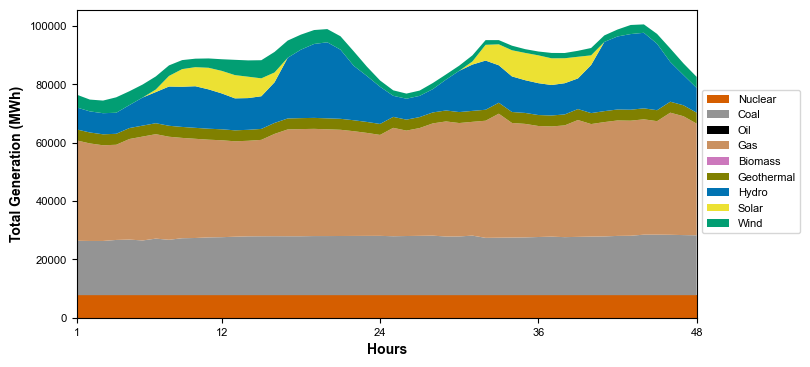

<Figure size 640x480 with 0 Axes>

In [8]:
# Plot total generation by type for the duration of our simulation
fig, ax = plt.subplots(figsize=(8,4))

ax.stackplot(range(1, total_hours+1), generation_timeseries.values(), labels=generation_timeseries.keys(), 
             colors=['#D55E00', '#949494','#000000','#CA9161','#CC78BC','#808000','#0173B2','#ECE133','#029E73'])
ax.set_xlim([1,total_hours])
ax.set_xticks([1, 12, 24, 36, 48])
ax.set_xlabel('Hours', weight='bold', fontsize=10)
ax.set_ylabel('Total Generation (MWh)', weight='bold', fontsize=10)

fig.legend(loc='center left', bbox_to_anchor=(0.9, 0.5), ncol=1)

plt.show()
plt.clf()

In [9]:
# Display the generation mix in percentages
Total_generation_by_type = {gen_type: generation_timeseries[gen_type].sum() for gen_type in generation_timeseries.keys()}
Total_generation = np.sum(list(Total_generation_by_type.values()))

for gen_type in generation_timeseries.keys():
    print(f'Share of {gen_type} in generation mix is {round(Total_generation_by_type[gen_type]/Total_generation*100, 2)}%')

Share of Nuclear in generation mix is 8.74%
Share of Coal in generation mix is 22.56%
Share of Oil in generation mix is 0.0%
Share of Gas in generation mix is 41.69%
Share of Biomass in generation mix is 0.0%
Share of Geothermal in generation mix is 4.25%
Share of Hydro in generation mix is 15.94%
Share of Solar in generation mix is 2.99%
Share of Wind in generation mix is 3.84%
